In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.sample(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1485,ham,(I should add that I don't really care and if ...,NaN,NaN,NaN
3150,ham,Yeah but which is worse for i,NaN,NaN,NaN


In [55]:
df.shape

(5572, 5)

In [56]:
# Line of Action

# Data Cleaning
# EDA
# Feature Engineering
# Text Preprocessing
# Model Building
# Evaluation
# Improvement


In [57]:
#1 Data Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [58]:
# Since very few non null values is present in the last three columns it is dropped as of no use.

df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'],inplace = True)
df.sample(5)

,v1,v2
2432,ham,Really dun bluff me leh... U sleep early too. ...
4314,ham,Captain is in our room:)
4483,ham,Shopping? Eh ger i toking abt syd leh...Haha
2118,spam,U can WIN å£100 of Music Gift Vouchers every w...
2494,ham,You at mu? You should try to figure out how mu...


In [59]:
# Renaming the Columns

df.rename(columns={'v1':'target','v2':'text'},inplace = True)
df.sample(5)

,target,text
1706,ham,Yes! I am a one woman man! Please tell me your...
2210,ham,Just wanted to say holy shit you guys weren't ...
4753,ham,Ok lor... Or u wan me go look 4 u?
175,ham,Let me know when you've got the money so carlo...
525,ham,Hi i won't b ard 4 christmas. But do enjoy n m...


In [60]:
# Turning the target column into classes

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [61]:
df['target'] = encoder.fit_transform(df['target'])
df.sample(2)

,target,text
2655,0,Great! I have to run now so ttyl!
2887,0,I take it we didn't have the phone callon Frid...


In [62]:
df.isnull().sum()

,0
target,0
text,0


In [63]:
#checking of the Duplicate value

df.duplicated().sum()

np.int64(403)

In [64]:
#Dropping the Duplicate Value

df.drop_duplicates(keep = 'first',inplace = True)

In [65]:
df.shape

(5169, 2)

In [66]:
# 2. EDA

In [67]:
# Checking the Percentage of Spam and Non-Spam
p_not_spam = df[df['target'] == 0].shape[0]/df['target'].shape[0] *100
print('Percentage of not Spam is :',p_not_spam)
print('Percentage of Spam is :',(100 - p_not_spam))

Percentage of not Spam is : 87.3669955503966
Percentage of Spam is : 12.633004449603405


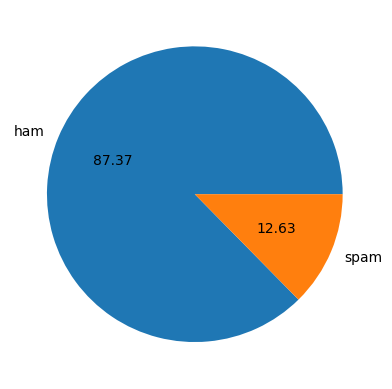

In [68]:
plt.pie(df['target'].value_counts(), labels = ['ham','spam'], autopct ="%0.2f")
plt.show()

In [69]:
pip install nltk

In [70]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [71]:
# Number of Characters in each message count

df['num_character'] = df['text'].apply(len)
df.sample(2)

,target,text,num_character
1999,0,LMAO where's your fish memory when I need it?,45
4054,0,When is school starting. Where will you stay. ...,180


In [72]:
# Number of Words in each message count

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words
1611,0,645,3,1
4570,0,\CHA QUITEAMUZING THATåÕSCOOL BABE,34,4


In [73]:
# No of sentence in each message count

df['num_sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.sample(2)

,target,text,num_character,num_words,num_sent
4073,0,A lot of this sickness thing going round. Take...,84,20,4
4118,0,Hiya do u like the hlday pics looked horrible ...,116,27,3


In [74]:
# Complete Overview of all messages character count, Sentence Count,sentence count
df[['num_character','num_words','num_sent']].describe()


,num_character,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [75]:
# no of ham messages overview

df[df['target'] == 0][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [76]:
# no of spam messages overview

df[df['target'] == 1][['num_character','num_words','num_sent']].describe()

,num_character,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_character', ylabel='Count'>

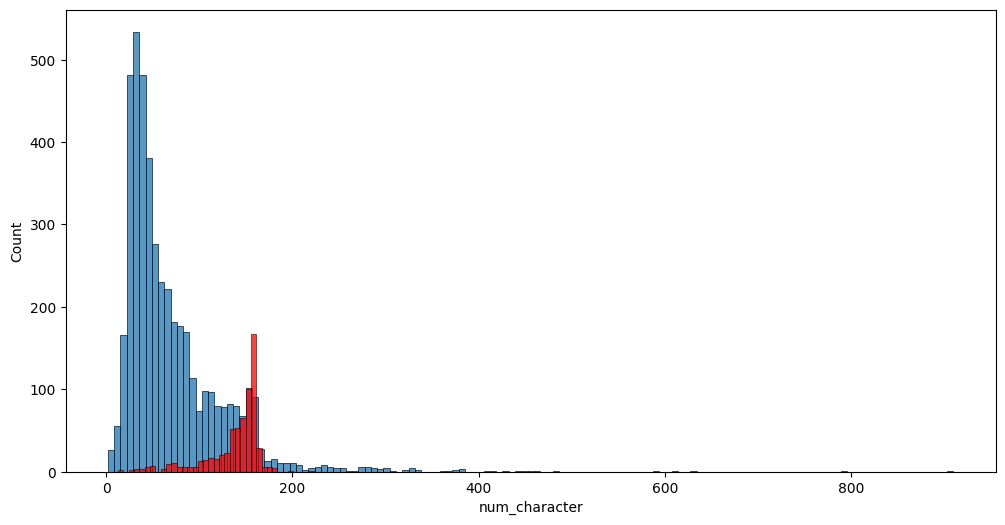

In [77]:
# We can observe that the spam messages is larger as compared to the not spam messages
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'],color='red')

<Axes: xlabel='num_sent', ylabel='Count'>

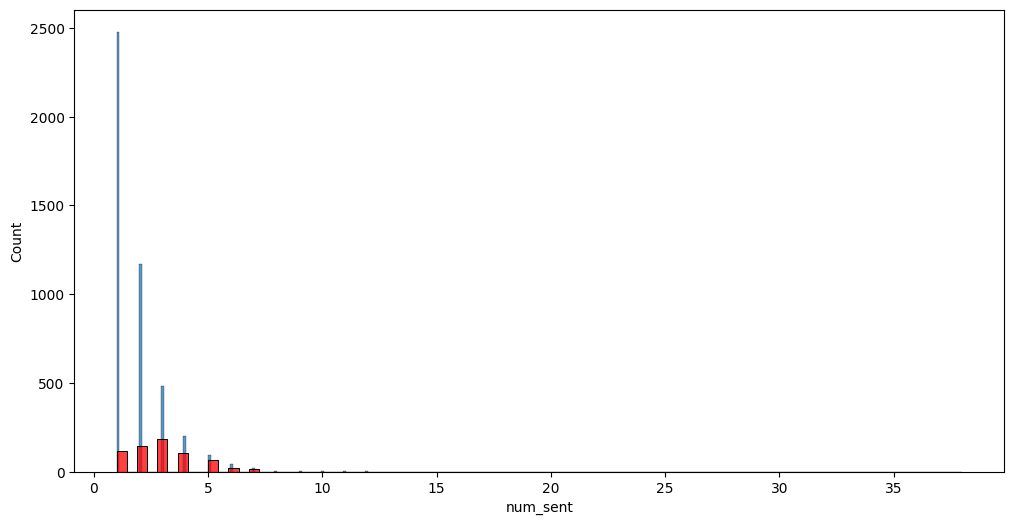

In [78]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_sent'])
sns.histplot(df[df['target'] == 1]['num_sent'],color='red')

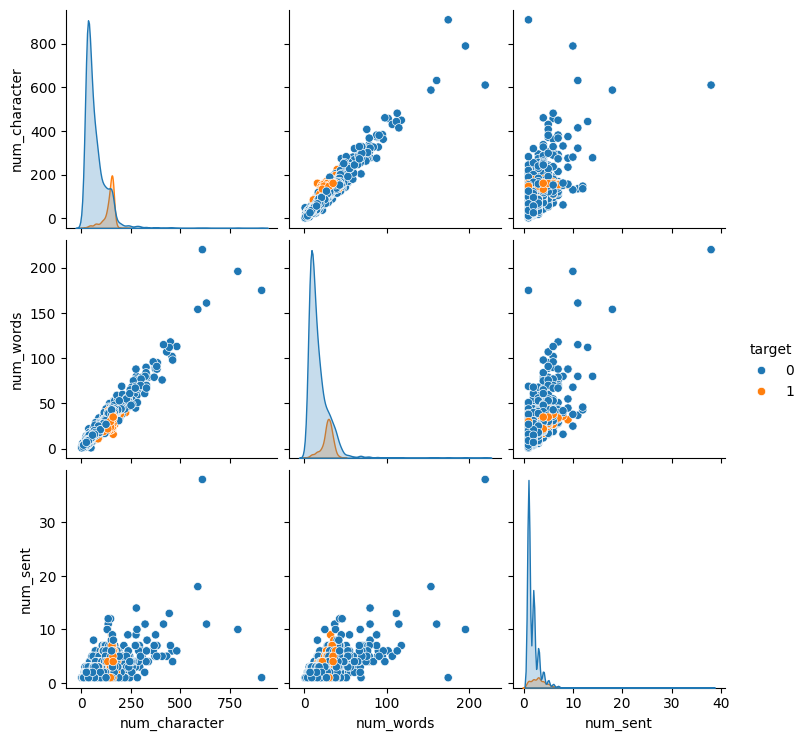

In [79]:
sns.pairplot(df,hue='target')

<Axes: >

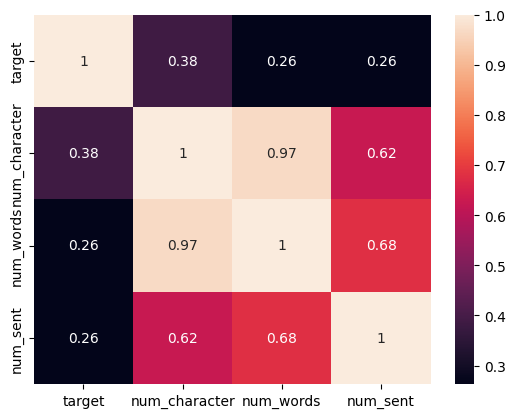

In [80]:
sns.heatmap(df[['target','num_character','num_words','num_sent']].corr(),annot=True)

In [81]:
#3. Data Preprocessing
# a. Lower case
# b. Tokenisation
# c. Remove special characters
# d. Remove stop words and Punctuation
# e. Stemming

In [82]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')
import string
string.punctuation

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [83]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [84]:
def trans_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [85]:
trans_text(df['text'][1])

'ok lar joke wif u oni'

In [86]:
df['transformed_text'] = df['text'].apply(trans_text)

In [87]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')


In [88]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))

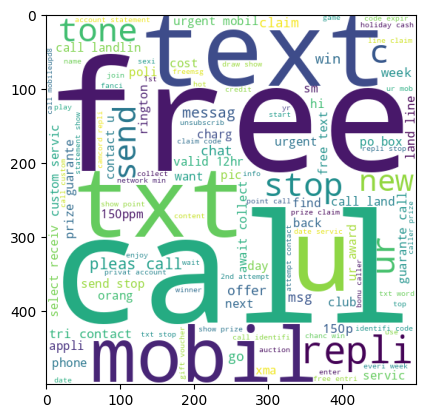

In [89]:
plt.imshow(spam_wc)

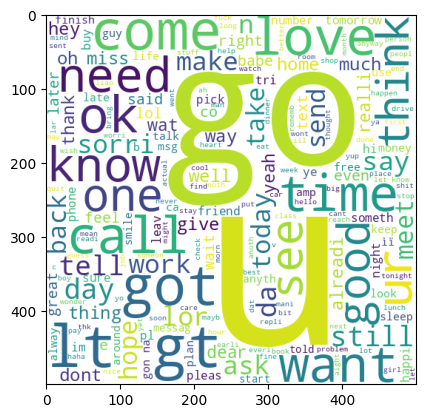

In [90]:
not_spam = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.imshow(not_spam)

In [91]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

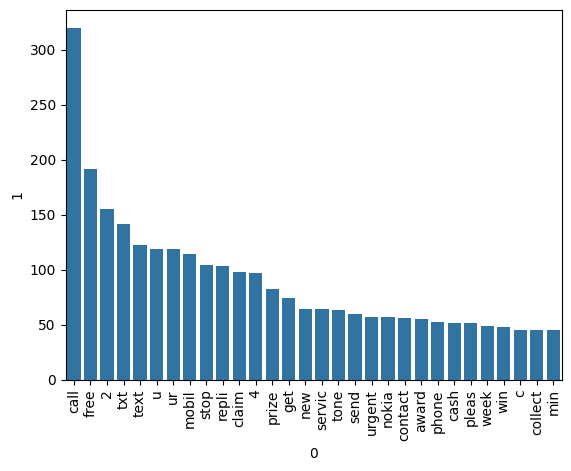

In [92]:
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

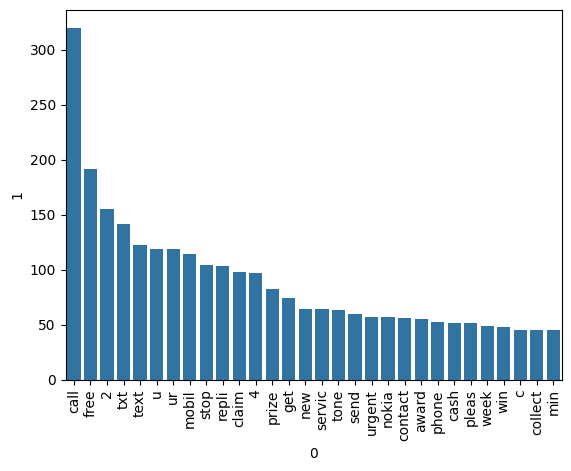

In [93]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [114]:
# Model Building

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [115]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [116]:
x.shape

(5169, 6708)

In [117]:
y = df['target'].values

In [118]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [121]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
GNB = GaussianNB()
BNB = BernoulliNB()
MNB = MultinomialNB()
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [122]:
GNB.fit(x_train,y_train)
pred1 = GNB.predict(x_test)
print(accuracy_score(y_test,pred1))
print(confusion_matrix(y_test,pred1))
print(precision_score(y_test,pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [123]:
BNB.fit(x_train,y_train)
pred2 = BNB.predict(x_test)
print(accuracy_score(y_test,pred2))
print(confusion_matrix(y_test,pred2))
print(precision_score(y_test,pred2))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [124]:
MNB.fit(x_train,y_train)
pred3 = MNB.predict(x_test)
print(accuracy_score(y_test,pred3))
print(confusion_matrix(y_test,pred3))
print(precision_score(y_test,pred3))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [125]:
# tfidf -> MNB (Good Precision and Accuracy)

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [128]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [136]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [134]:
def funct(model_name,x_train,y_train,x_test,y_test):
  model_name.fit(x_train,y_train)
  accr = accuracy_score(y_test,model_name.predict(x_test))
  conf = confusion_matrix(y_test,model_name.predict(x_test))
  prec = precision_score(y_test,model_name.predict(x_test))

  return accr,prec

In [135]:
funct(knc,x_train,y_train,x_test,y_test)

(0.8965183752417795, 1.0)

In [139]:
accuracy_scores = []
precision_scores = []

for name,model_name in clfs.items():

    current_accuracy,current_precision = funct(model_name, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.971953578336557
Precision -  0.9393939393939394
For  KN
Accuracy -  0.8965183752417795
Precision -  1.0
For  NB
Accuracy -  0.9613152804642167
Precision -  0.9906542056074766
For  DT
Accuracy -  0.9361702127659575
Precision -  0.8211382113821138
For  LR
Accuracy -  0.9439071566731141
Precision -  0.865546218487395
For  RF
Accuracy -  0.9700193423597679
Precision -  0.9913793103448276
For  AdaBoost
Accuracy -  0.9148936170212766
Precision -  0.7878787878787878
For  BgC
Accuracy -  0.9613152804642167
Precision -  0.8776978417266187
For  ETC
Accuracy -  0.9738878143133463
Precision -  0.9916666666666667
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9519230769230769
For  xgb
Accuracy -  0.9738878143133463
Precision -  0.946969696969697


In [143]:
performance_df = pd.DataFrame({'Algorithm_name':clfs.keys(), 'Accuracy' : accuracy_scores,
                               'Precision' : precision_scores}).sort_values('Precision',ascending = False)
performance_df

,Algorithm_name,Accuracy,Precision
1,KN,0.896518,1.000000
8,ETC,0.973888,0.991667
5,RF,0.970019,0.991379
2,NB,0.961315,0.990654
9,GBDT,0.950677,0.951923
10,xgb,0.973888,0.946970
0,SVC,0.971954,0.939394
7,BgC,0.961315,0.877698
4,LR,0.943907,0.865546
3,DT,0.936170,0.821138


In [145]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))